In [ ]:
!pip install -Uq pymcel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.6 MB/s eta 0:00:00


In [ ]:
!pip install -Uq rebound

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 830.6/830.6 kB 10.1 MB/s eta 0:00:00


In [ ]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import rebound as rb
from astroquery.jplhorizons import Horizons
from astropy.time import Time

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


Consultando trayectoria desde 2025-04-08 hasta 2026-04-08...


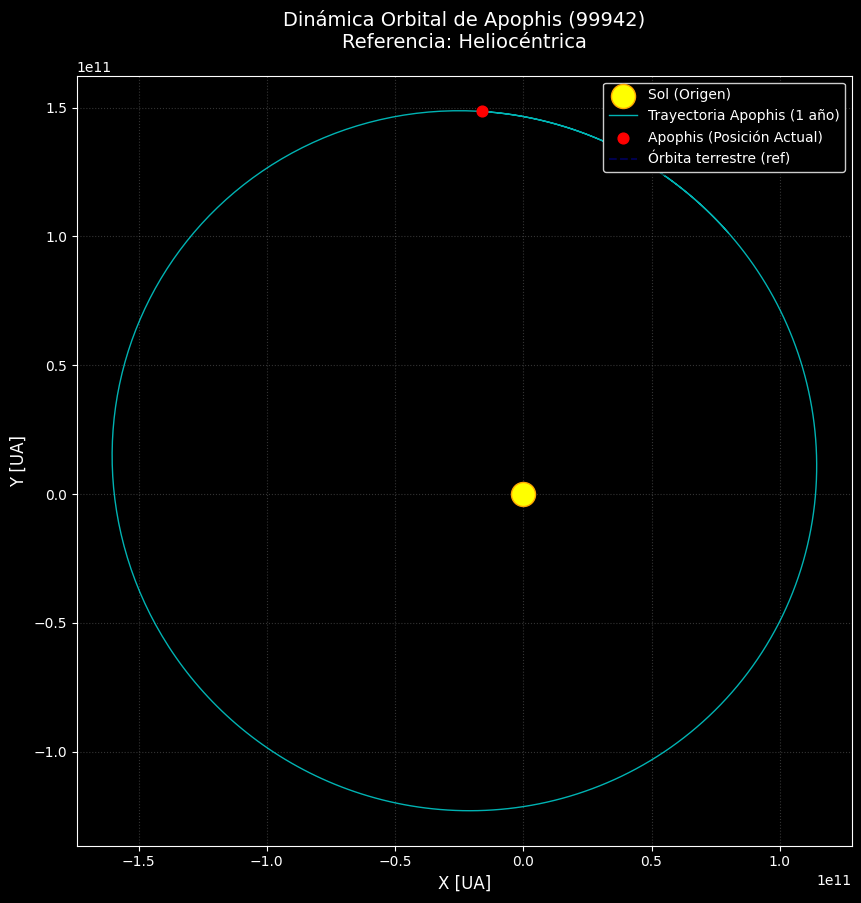

In [ ]:
# 1. Configuración de fechas (Desde hoy hasta un año atrás)
# Usamos la fecha actual del sistema (2026)
fecha_final = datetime.now()
fecha_inicio = fecha_final - timedelta(days=365)

# Formateo de fechas para la consulta a JPL Horizons
start_str = fecha_inicio.strftime('%Y-%m-%d')
stop_str = fecha_final.strftime('%Y-%m-%d')

print(f"Consultando trayectoria desde {start_str} hasta {stop_str}...")

# 2. Consulta a JPL Horizons
# ID de Apophis: 99942
# location='@Sun' pone al Sol en el origen (0,0,0)
tabla, jd, X_raw = pc.consulta_horizons(
    id='99942',
    location='@Sun',
    epochs={'start': start_str, 'stop': stop_str, 'step': '1d'}
)

# 3. CORRECCIÓN DEL ERROR: Convertir a array de NumPy para evitar InvalidIndexError
X_total = np.array(X_raw)

# Extraer posiciones X e Y (están en las primeras dos columnas)
x_apophis = X_total[:, 0]
y_apophis = X_total[:, 1]

# 4. Generación de la gráfica 2D
plt.figure(figsize=(10, 10))
plt.style.use('dark_background') # Fondo espacial

# Dibujar al Sol en el centro
plt.scatter(0, 0, color='yellow', s=300, label='Sol (Origen)', edgecolors='orange', zorder=5)

# Dibujar la "estela" (toda la trayectoria del año)
plt.plot(x_apophis, y_apophis, color='cyan', linestyle='-', linewidth=1, alpha=0.7, label='Trayectoria Apophis (1 año)')

# Dibujar la posición actual de Apophis (el último punto registrado)
plt.scatter(x_apophis[-1], y_apophis[-1], color='red', s=60, label='Apophis (Posición Actual)', zorder=6)

# Añadir la órbita de la Tierra como referencia (Círculo de radio 1 UA aprox.)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color='blue', linestyle='--', alpha=0.3, label='Órbita terrestre (ref)')

# Personalización técnica de la gráfica
plt.title(f'Dinámica Orbital de Apophis (99942)\nReferencia: Heliocéntrica', fontsize=14, pad=20)
plt.xlabel('X [UA]', fontsize=12)
plt.ylabel('Y [UA]', fontsize=12)
plt.axis('equal') # Crucial para no deformar la elipse de la órbita
plt.grid(color='gray', linestyle=':', alpha=0.4)
plt.legend(loc='upper right', frameon=True, shadow=True)

In [ ]:
fecha_inicio = '2026-03-11'

sim = rb.Simulation()
sim.units = ('yr', 'AU', 'Msun')
sim.add('Sun',date= fecha_inicio)
sim.add('Apophis',date= fecha_inicio)



Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


/usr/local/lib/python3.12/dist-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


In [ ]:
ts = np.linspace(0, 3.01, 100)
pos_apophis_helio = np.zeros((100, 3))

def integrador(ts):

  for i, t in enumerate(ts):
      sim.integrate(t)

      # Extraemos las partículas
      sol = sim.particles[0]
      apophis = sim.particles[1]

      # Calculamos la posición relativa (Heliocéntrica)
      x_rel = apophis.x - sol.x
      y_rel = apophis.y - sol.y
      z_rel = apophis.z - sol.z

      # Guardamos en nuestro arreglo
      pos_apophis_helio[i] = [x_rel, y_rel, z_rel]

      return pos_apophis_helio

Consultando a JPL Horizons (en bloques para evitar error 502)...


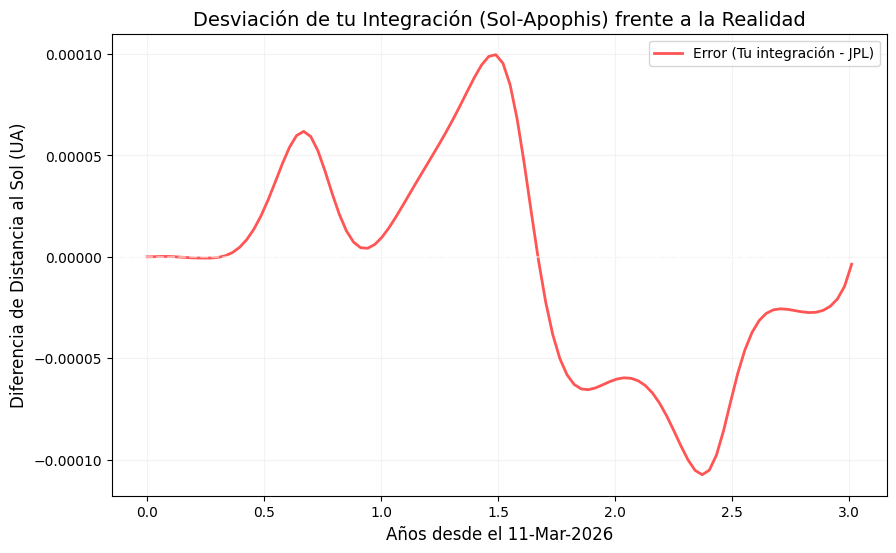

In [ ]:
r_rebound_mag = np.linalg.norm(pos_apophis_helio, axis=1)

# 2. Convertir tu tiempo 'ts' a Julian Dates (JD) para el JPL
# Tu integración está en años (yr = 365.25 días)
jd_inicial = Time(fecha_inicio).jd
jds_integracion = jd_inicial + (ts * 365.25)

# 3. Descargar datos del JPL Horizons usando tus tiempos exactos
r_jpl_mag = []

print("Consultando a JPL Horizons (en bloques para evitar error 502)...")
# Dividimos tus 100 tiempos en dos bloques de 50
bloques_jd = [jds_integracion[:50], jds_integracion[50:]]

for bloque in bloques_jd:
    obj = Horizons(id='Apophis', location='@sun', epochs=bloque.tolist())
    vectores = obj.vectors()
    # Guardamos la columna 'range' (distancia al Sol)
    r_jpl_mag.extend(vectores['range'])

r_jpl_mag = np.array(r_jpl_mag)

# 4. Calcular la resta uno a uno (Tu código vs Realidad)
diferencia = r_rebound_mag - r_jpl_mag

# 5. Generar la gráfica
plt.figure(figsize=(10, 6))
plt.plot(ts, diferencia, color='#FF5555', linewidth=2, label='Error (Tu integración - JPL)')
plt.axhline(0, color='white', linestyle='--', alpha=0.5)

plt.title("Desviación de tu Integración (Sol-Apophis) frente a la Realidad", fontsize=14)
plt.xlabel("Años desde el 11-Mar-2026", fontsize=12)
plt.ylabel("Diferencia de Distancia al Sol (UA)", fontsize=12)
plt.grid(True, alpha=0.15)
plt.legend()
plt.style.use('dark_background')
plt.show()